# Exploring Pokemon Data with Unsupervised Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
from math import pi

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.stem import WordNetLemmatizer

import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

---
## Understanding the Data

In [2]:
pokemon  = pd.read_csv('pokemon_complete.csv')
moves    = pd.read_csv('moves_complete.csv')
learnset = pd.read_csv('learnset_complete.csv')

stat_cols = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']

moves_per_pokemon = learnset.groupby('pokemon_id').size()

print(f"Pokemon:   {pokemon.shape[0]}")
print(f"Moves:     {moves.shape[0]}")
print(f"Learnset:  {learnset.shape[0]} links")
print(f"Moves per Pokemon: mean={moves_per_pokemon.mean():.1f}, "
      f"median={moves_per_pokemon.median():.0f}, "
      f"range=[{moves_per_pokemon.min()}, {moves_per_pokemon.max()}]")

Pokemon:   1025
Moves:     797
Learnset:  78458 links
Moves per Pokemon: mean=76.5, median=77, range=[1, 375]


### Are there missing values? How do we handle them?

In [3]:
for name, df in [('Pokemon', pokemon), ('Moves', moves), ('Learnset', learnset)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"{name}:")
        for col, cnt in miss.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
        print()
    else:
        print(f"{name}: no missing values\n")

Pokemon:
  type_2: 499 (48.7%)
  ability_2: 165 (16.1%)
  ability_3: 495 (48.3%)

Moves:
  power: 287 (36.0%)
  accuracy: 204 (25.6%)
  effect_text: 94 (11.8%)
  short_effect_text: 94 (11.8%)

Learnset: no missing values



Three kinds of missingness, each with a different cause:

- **`type_2`** (49%): mono-typed Pokemon don't have a secondary type. This is structural, not an error. We fill with `'none'`.
- **`power`** (36%): status moves don't deal damage, so they have no base power. Fill with 0.
- **`accuracy`** (26%): these are moves that **bypass the accuracy check entirely** — Swords Dance, Substitute, Reflect, etc. They always succeed. Filling with 0 would be misleading (it would look like they always miss); we fill with **100** since they effectively never fail.
- **`effect_text`** (12%): some moves lack descriptions. Fill with empty string for TF-IDF processing.
- **`ability_2`, `ability_3`**: not all Pokemon have multiple abilities. We don't use these columns.

In [4]:
pokemon['type_2'] = pokemon['type_2'].fillna('none')
moves['power']    = moves['power'].fillna(0)
moves['accuracy'] = moves['accuracy'].fillna(100)  # these moves never miss
moves['effect_text'] = moves['effect_text'].fillna('')
moves['short_effect_text'] = moves['short_effect_text'].fillna('')

### Is the data balanced across types?

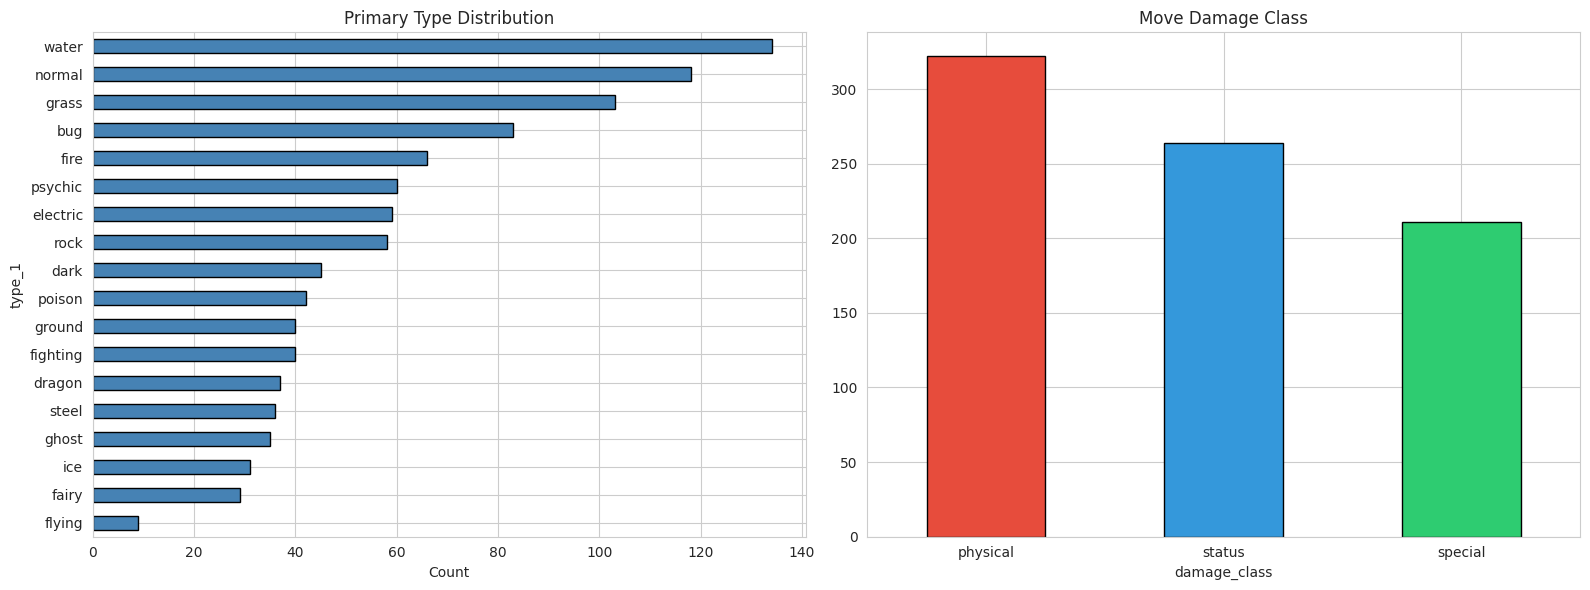

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pokemon['type_1'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Primary Type Distribution'); axes[0].invert_yaxis(); axes[0].set_xlabel('Count')

dc = moves['damage_class'].value_counts()
dc.plot(kind='bar', ax=axes[1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[1].set_title('Move Damage Class'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

No, the data is clearly unbalanced. Water (~130) and Normal (~110) dominate, while Ice, Ghost, and Fairy sit around 50-60 each. This matters for clustering: K-Means tends to split large groups and merge small ones because it assumes equally-sized clusters. HDBSCAN handles this better since it adapts to local density.

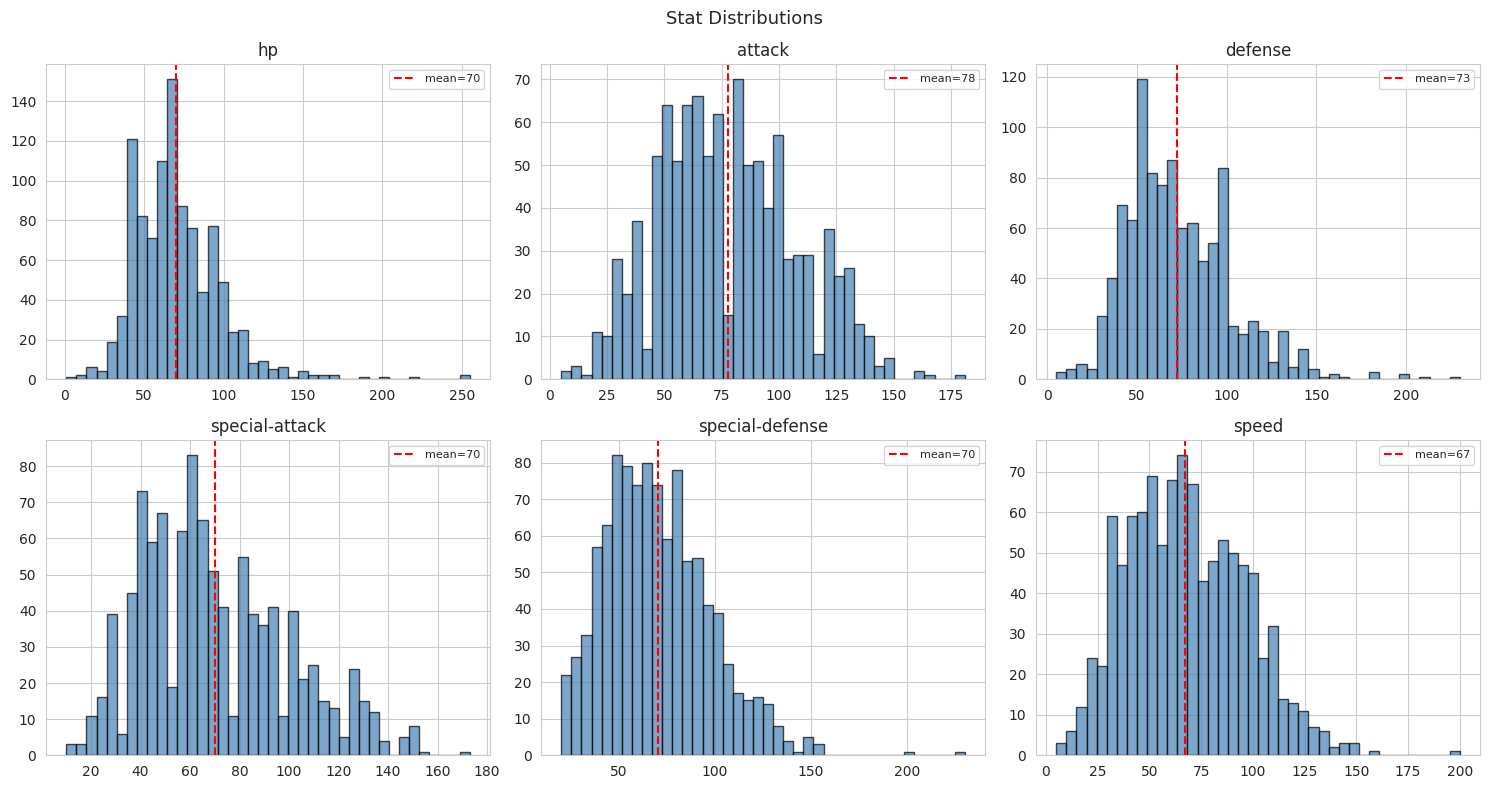

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(stat_cols):
    ax = axes[i//3, i%3]
    ax.hist(pokemon[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(pokemon[col].mean(), color='red', ls='--', label=f'mean={pokemon[col].mean():.0f}')
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle('Stat Distributions', fontsize=13)
plt.tight_layout(); plt.show()

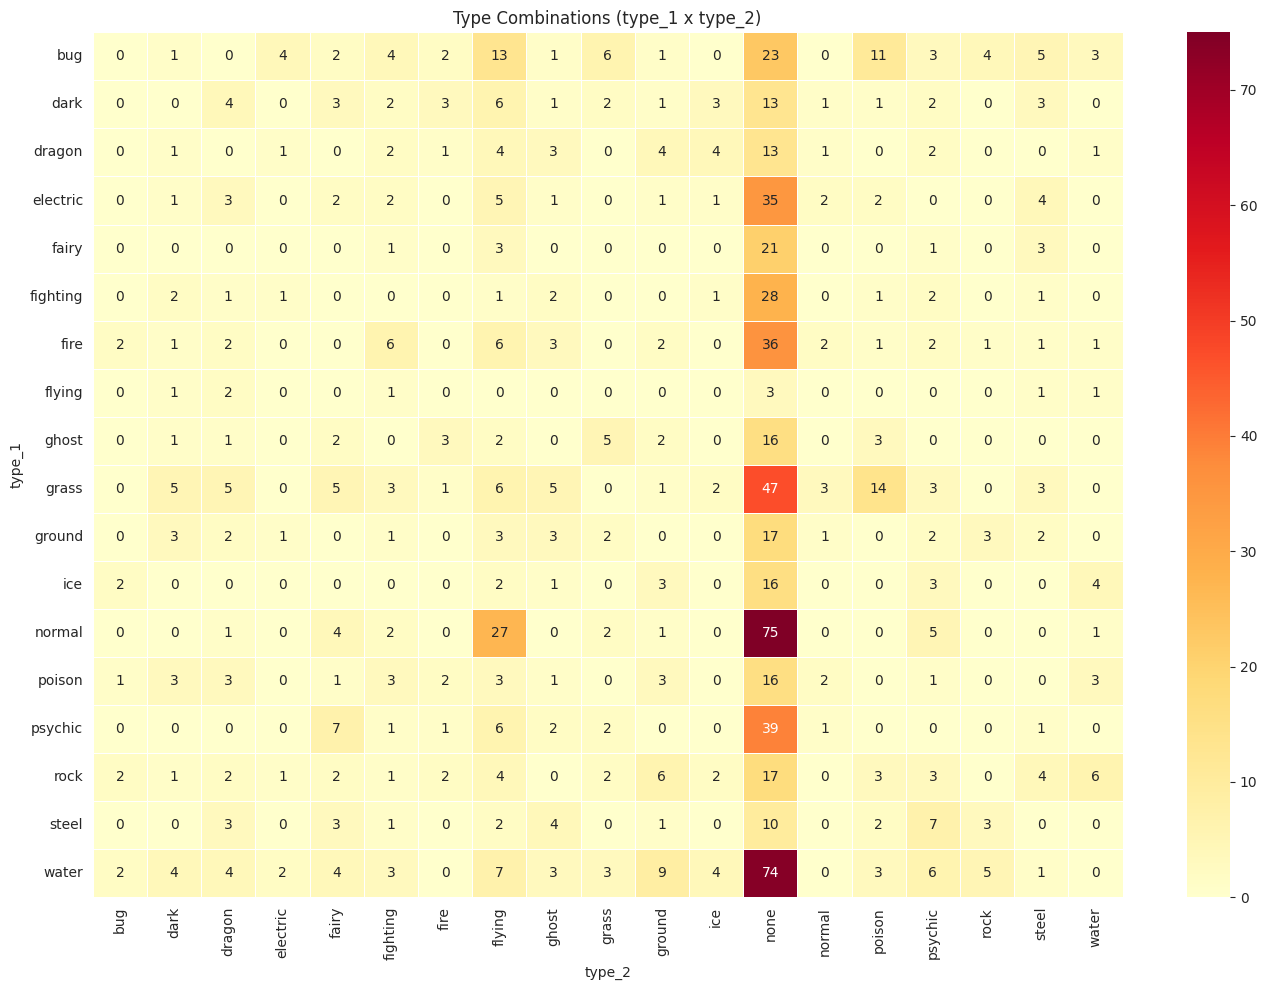

In [7]:
# Type combination heatmap
ct = pokemon.groupby(['type_1','type_2']).size().reset_index(name='n')
piv = ct.pivot_table(index='type_1', columns='type_2', values='n', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(piv, annot=True, fmt='g', cmap='YlOrRd', linewidths=.5, ax=ax)
ax.set_title('Type Combinations (type_1 x type_2)')
plt.tight_layout(); plt.show()

---
## Do Pokemon naturally group into distinct archetypes based on their statistics?

### Data preparation

In [8]:
# StandardScaler: zero mean, unit variance.
# Necessary because stats have different scales (HP ~1-255, Speed ~5-200) —
# without scaling, high-magnitude stats dominate distance calculations.
scaler = StandardScaler()
X_raw = scaler.fit_transform(pokemon[stat_cols])

### What's wrong with PCA + K-Means

Before explaining our approach, let's look at what the standard pipeline actually produces.

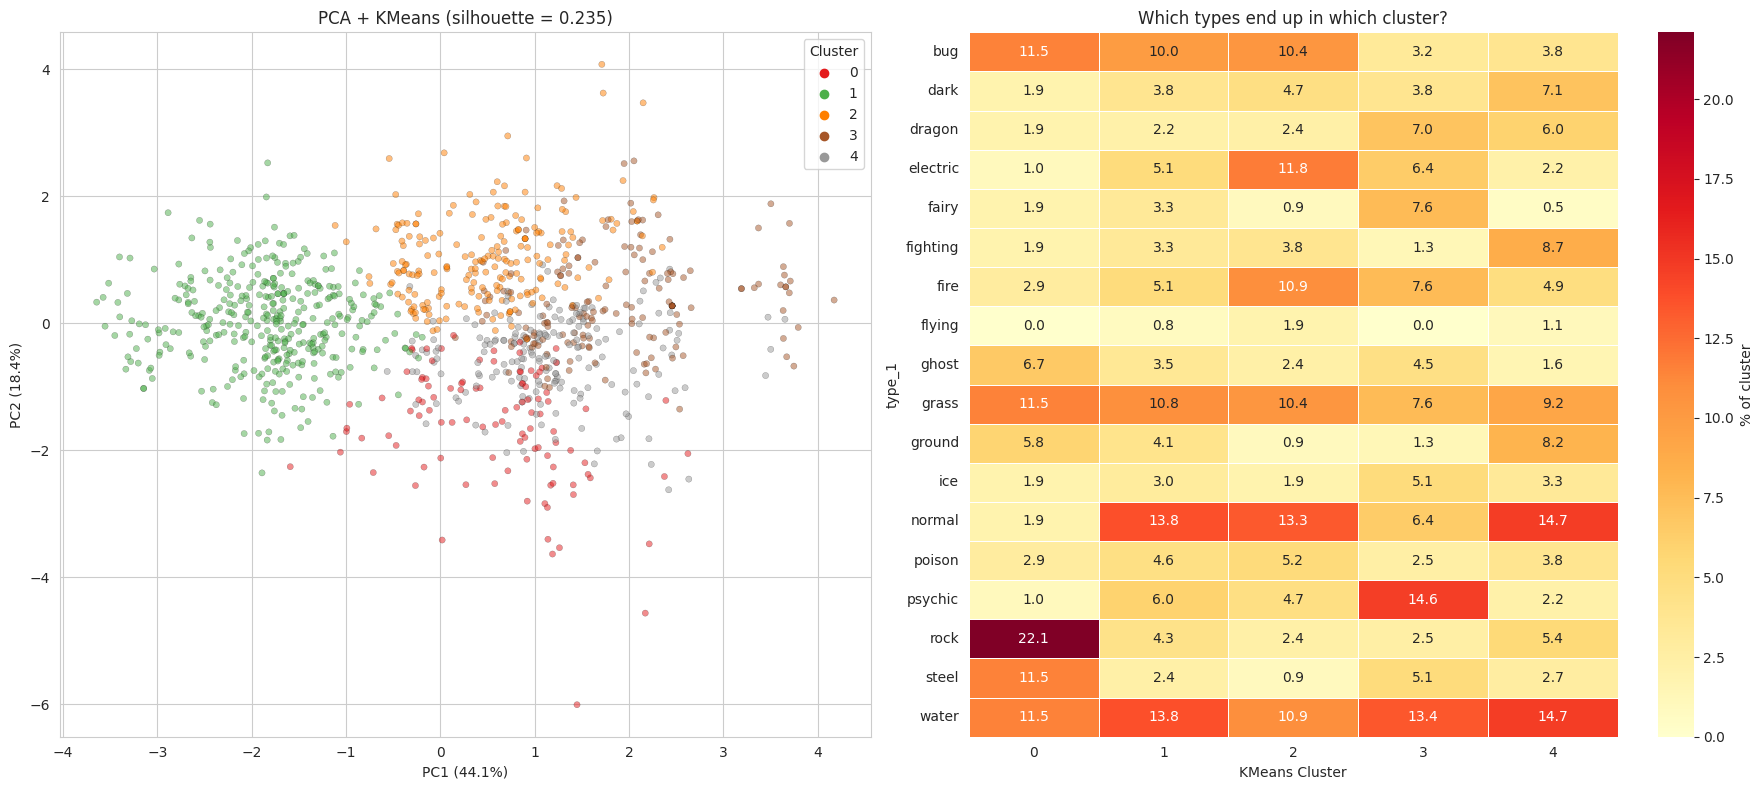

In [9]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_raw)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
pokemon['km_label'] = km.fit_predict(X_raw)
sil_km = silhouette_score(X_raw, pokemon['km_label'])

# Type composition per cluster — the key diagnostic
type_km = pd.crosstab(pokemon['type_1'], pokemon['km_label'], normalize='columns') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=pokemon['km_label'],
                     cmap='Set1', alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'PCA + KMeans (silhouette = {sil_km:.3f})')
for cl_id in sorted(pokemon['km_label'].unique()):
    axes[0].scatter([], [], c=[plt.cm.Set1(cl_id/max(pokemon['km_label'].max(),1))], label=f'{cl_id}')
axes[0].legend(title='Cluster')

sns.heatmap(type_km.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, ax=axes[1], cbar_kws={'label': '% of cluster'})
axes[1].set_title('Which types end up in which cluster?')
axes[1].set_xlabel('KMeans Cluster')

plt.tight_layout(); plt.show()

The heatmap tells the whole story: **every K-Means cluster contains the same mix of types.** Water, Normal, and Grass show up in all of them. The clusters only separate weak Pokemon from strong ones — PC1 is essentially "total stats."

Three problems at play:
1. PCA sees 6 numbers (the stats) and knows nothing about types. A Water-type with 100 Attack and a Fighting-type with 100 Attack look identical.
2. K-Means assumes spherical, equal-size clusters. Some archetypes (Electric sweepers) are small and tight; others (Normal-types) are large and diffuse.
3. K-Means forces every point into a cluster, even when a Pokemon doesn't clearly fit anywhere.

### Our approach: UMAP + HDBSCAN

The fix has three parts:
- **Add type information** to the features (one-hot encoding alongside stats)
- **UMAP** instead of PCA — preserves non-linear structure, finds "islands" in the data that PCA misses
- **HDBSCAN** instead of K-Means — finds clusters of varying density, determines k automatically, labels ambiguous points as noise

In [10]:
# Combine scaled stats with one-hot encoded types
type_dummies = pd.get_dummies(pokemon[['type_1', 'type_2']], prefix=['t1', 't2'])
X_typed = np.hstack([X_raw, type_dummies.values])
X_typed = StandardScaler().fit_transform(X_typed)

print(f"Features: {X_typed.shape[1]} (6 stats + {type_dummies.shape[1]} type indicators)")

Features: 43 (6 stats + 37 type indicators)


In [11]:
# UMAP: 5D for clustering (more structure), 2D for visualization
X_5d = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0, random_state=42).fit_transform(X_typed)
X_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42).fit_transform(X_typed)

### Parameter selection

In [12]:
print(f"{'mcs':>5s} {'ms':>4s} {'k':>4s} {'noise':>6s} {'noise%':>7s} {'silhouette':>10s}")
print("-"*42)
for mcs in [20, 30, 40, 50, 60, 80]:
    for ms in [5, 10]:
        lab = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit_predict(X_5d)
        nc = len(set(lab)) - (1 if -1 in lab else 0)
        nn = (lab == -1).sum()
        if nc >= 3:
            m = lab != -1
            s = silhouette_score(X_5d[m], lab[m])
            flag = " <--" if mcs==50 and ms==5 else ""
            print(f"{mcs:>5d} {ms:>4d} {nc:>4d} {nn:>6d} {nn/1025*100:>6.1f}% {s:>10.4f}{flag}")

  mcs   ms    k  noise  noise% silhouette
------------------------------------------
   20    5   28     54    5.3%     0.7843
   20   10   27     40    3.9%     0.7868
   30    5   15     80    7.8%     0.6638
   30   10   15     80    7.8%     0.6638
   40    5   13    115   11.2%     0.6550
   40   10   13    115   11.2%     0.6550
   50    5    9    206   20.1%     0.6147 <--
   50   10    9    206   20.1%     0.6147
   60    5    9    206   20.1%     0.6147
   60   10    9    206   20.1%     0.6147
   80    5    6    272   26.5%     0.5614
   80   10    6    272   26.5%     0.5614


We go with `min_cluster_size=50`: 9 clusters, 20% noise, silhouette 0.615. Lower values (20-30) create too many micro-clusters; higher (80) starts merging distinct types.

In [13]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
pokemon['cluster'] = clusterer.fit_predict(X_5d)
pokemon['cluster_prob'] = clusterer.probabilities_

n_cl = len(set(pokemon['cluster'])) - (1 if -1 in pokemon['cluster'].values else 0)
n_noise = (pokemon['cluster'] == -1).sum()
mask = pokemon['cluster'] != -1
sil_hdb = silhouette_score(X_5d[mask], pokemon.loc[mask, 'cluster'])

print(f"Clusters: {n_cl}  |  Noise: {n_noise} ({n_noise/1025*100:.1f}%)")
print(f"Silhouette: {sil_hdb:.4f}  vs  KMeans: {sil_km:.4f}  ({sil_hdb/sil_km:.1f}x)")

Clusters: 9  |  Noise: 206 (20.1%)
Silhouette: 0.6147  vs  KMeans: 0.2347  (2.6x)


### Visualization

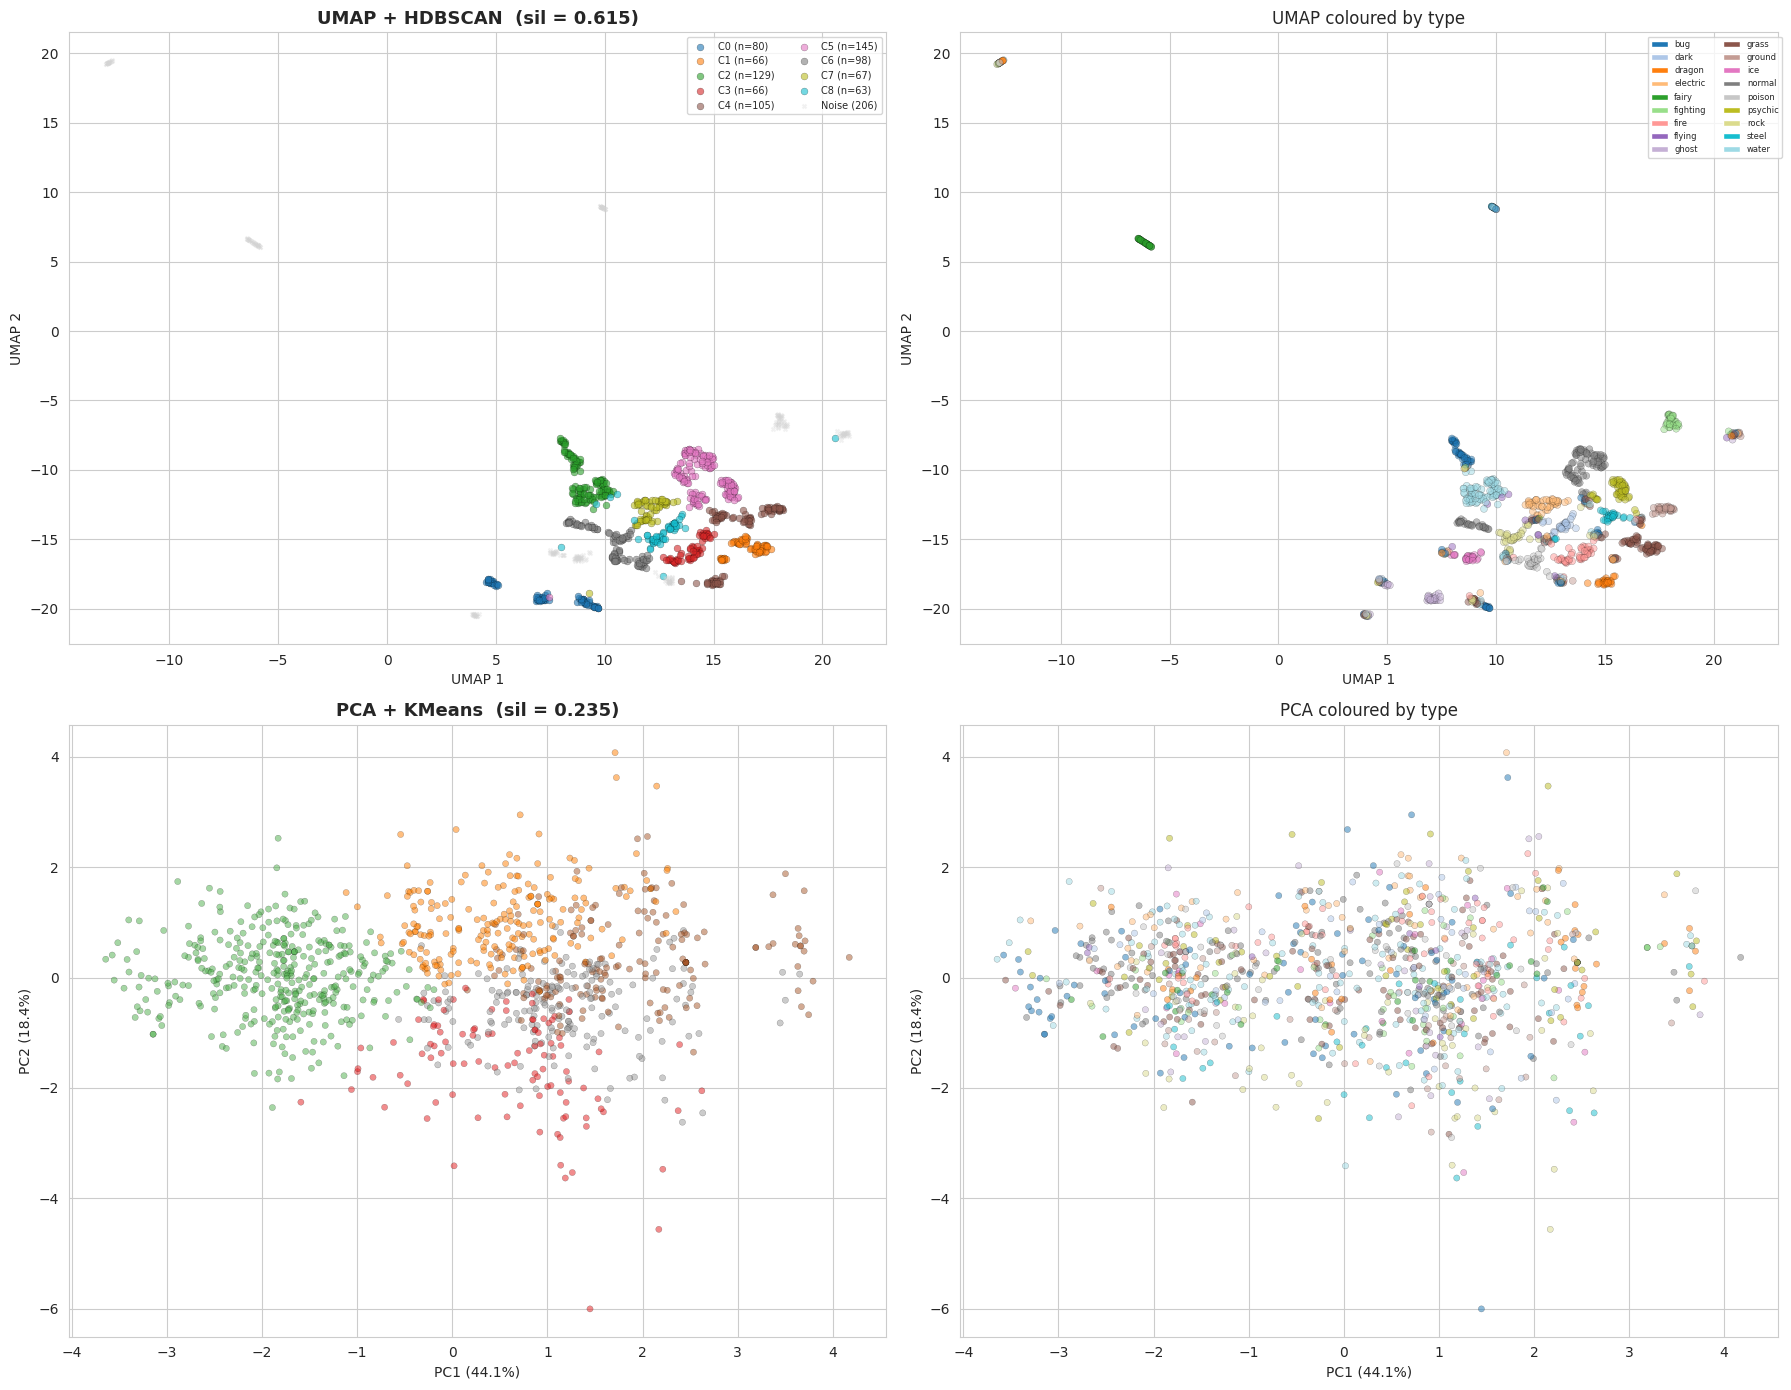

In [14]:
types_unique = sorted(pokemon['type_1'].unique())
type_map = {t: i for i, t in enumerate(types_unique)}
type_nums = pokemon['type_1'].map(type_map).values
cids = sorted([c for c in pokemon['cluster'].unique() if c != -1])

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top: UMAP + HDBSCAN
noise_m = pokemon['cluster'] == -1
for cid in cids:
    cm = pokemon['cluster'] == cid
    axes[0,0].scatter(X_2d[cm, 0], X_2d[cm, 1],
                      c=[plt.cm.tab10(cid/max(cids))], s=25, alpha=0.6,
                      label=f'C{cid} (n={cm.sum()})', edgecolors='k', linewidths=0.2)
axes[0,0].scatter(X_2d[noise_m, 0], X_2d[noise_m, 1],
                  c='lightgray', s=8, alpha=0.3, marker='x', label=f'Noise ({noise_m.sum()})')
axes[0,0].set_title(f'UMAP + HDBSCAN  (sil = {sil_hdb:.3f})', fontsize=13, fontweight='bold')
axes[0,0].legend(fontsize=7, ncol=2)

axes[0,1].scatter(X_2d[:, 0], X_2d[:, 1], c=type_nums, cmap='tab20',
                  alpha=0.5, s=25, edgecolors='k', linewidths=0.2)
from matplotlib.patches import Patch
tcols = plt.cm.tab20(np.linspace(0, 1, len(types_unique)))
axes[0,1].legend(handles=[Patch(facecolor=tcols[i], label=t) for i, t in enumerate(types_unique)],
                 fontsize=6, ncol=2, bbox_to_anchor=(1.01, 1))
axes[0,1].set_title('UMAP coloured by type')

# Bottom: PCA + KMeans
axes[1,0].scatter(X_pca[:, 0], X_pca[:, 1], c=pokemon['km_label'],
                  cmap='Set1', alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[1,0].set_title(f'PCA + KMeans  (sil = {sil_km:.3f})', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1,0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1], c=type_nums, cmap='tab20',
                  alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[1,1].set_title('PCA coloured by type')
axes[1,1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

for ax in axes[0]: ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()

### Type composition comparison

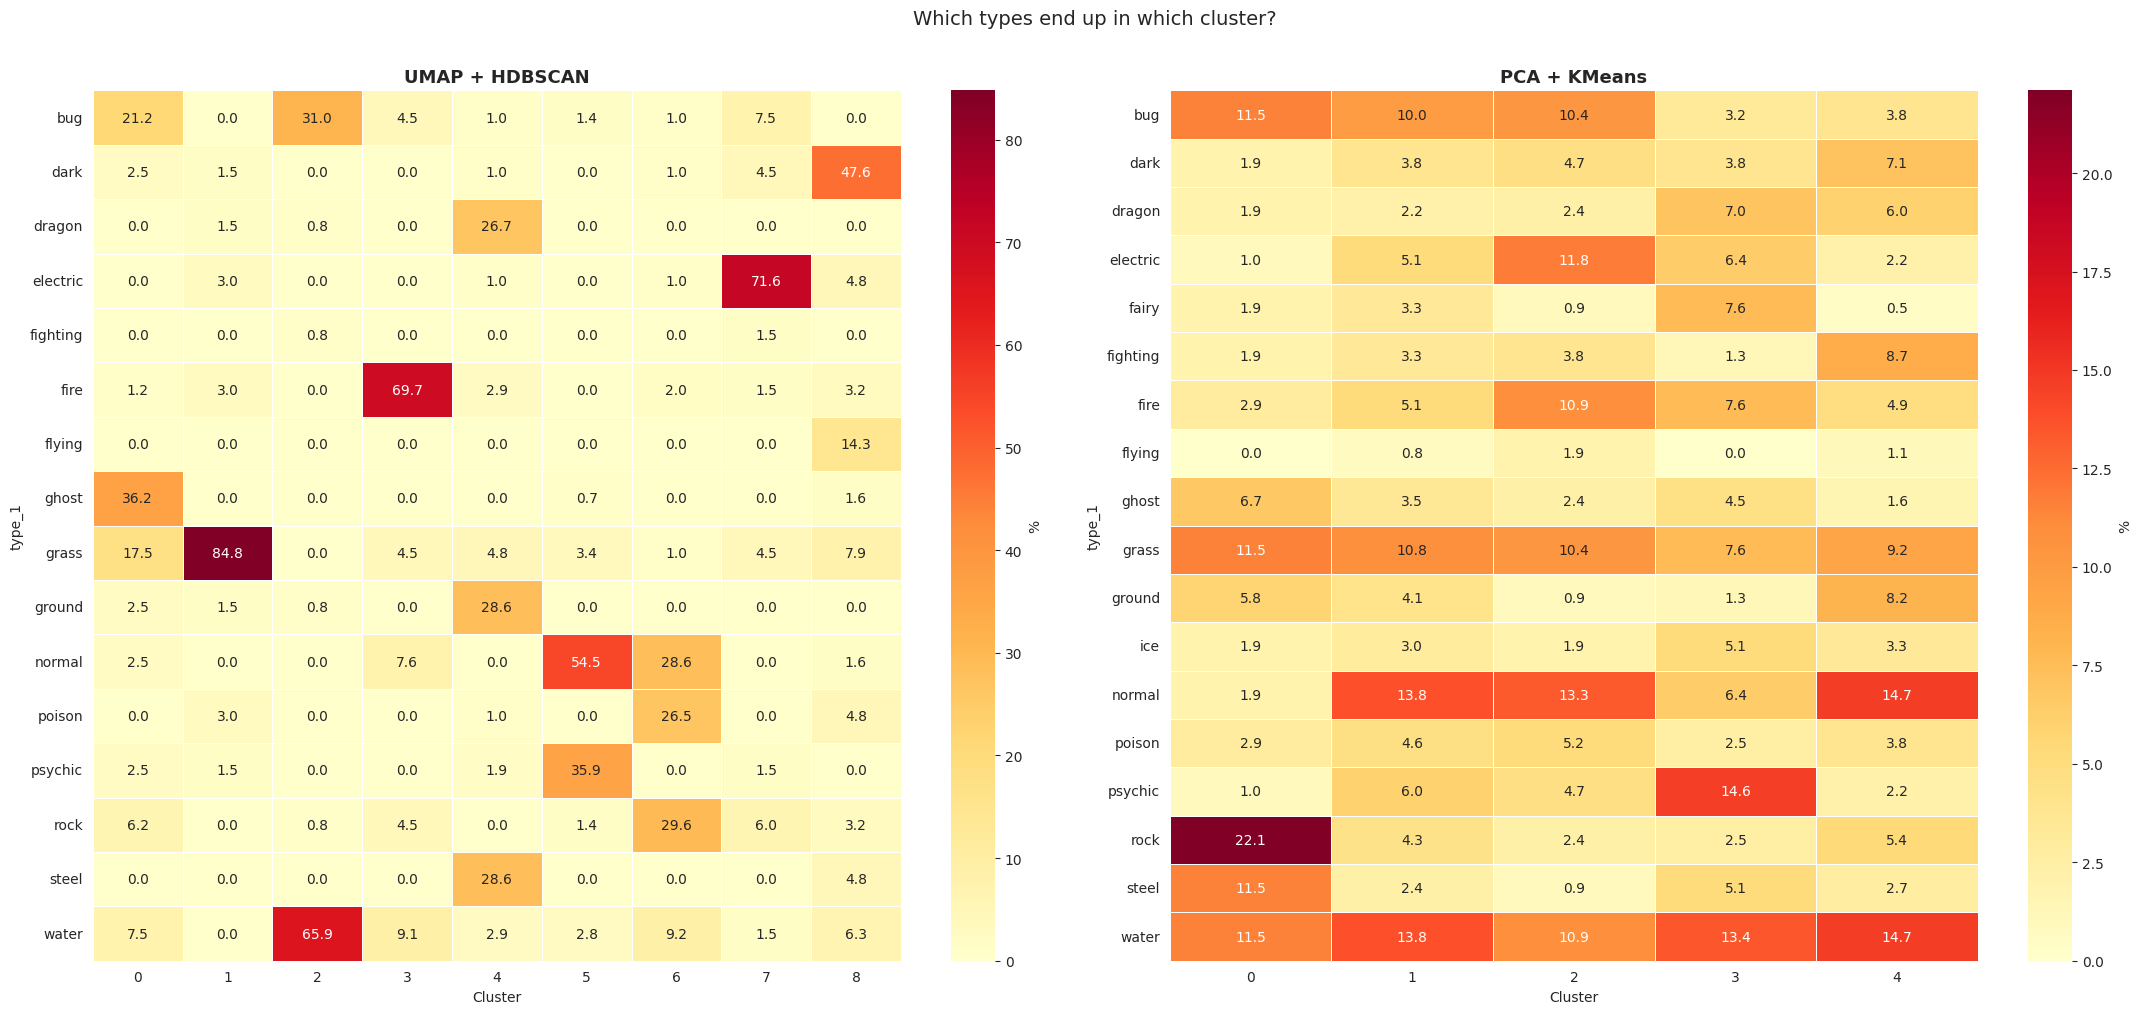

In [15]:
type_hdb = pd.crosstab(pokemon[mask]['type_1'], pokemon[mask]['cluster'],
                        normalize='columns') * 100

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(type_hdb.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, ax=axes[0], cbar_kws={'label':'%'})
axes[0].set_title('UMAP + HDBSCAN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster')

sns.heatmap(type_km.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, ax=axes[1], cbar_kws={'label':'%'})
axes[1].set_title('PCA + KMeans', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')

plt.suptitle('Which types end up in which cluster?', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### Cluster interpretation

In [16]:
pokemon['stat_total'] = pokemon[stat_cols].sum(axis=1)
atk = pokemon['attack'] + pokemon['special-attack']
dfn = pokemon['defense'] + pokemon['special-defense']
pokemon['orientation'] = np.where(atk > dfn*1.2, 'offensive',
                          np.where(dfn > atk*1.2, 'defensive', 'balanced'))

# Assign descriptive names
cluster_names = {}
for c in cids:
    cl = pokemon[pokemon['cluster'] == c]
    top_type = cl['type_1'].value_counts().index[0]
    ori = cl['orientation'].value_counts().index[0]
    if ori == 'defensive': role = 'Tanks'
    elif ori == 'offensive': role = 'Attackers'
    elif cl['speed'].mean() > 78: role = 'Sweepers'
    else: role = 'All-Rounders'
    cluster_names[c] = f"{top_type.capitalize()} {role}"

for c in cids:
    cl = pokemon[pokemon['cluster'] == c]
    tt = cl['type_1'].value_counts()
    pct = tt.iloc[0] / len(cl) * 100
    ex = cl.nlargest(5, 'stat_total')[['name','type_1']].values.tolist()
    
    print(f"C{c} \"{cluster_names[c]}\" ({len(cl)} Pokemon)")
    print(f"  Types: {tt.head(3).to_dict()} ({pct:.0f}% {tt.index[0]})")
    print(f"  Stats: HP={cl['hp'].mean():.0f} Atk={cl['attack'].mean():.0f} "
          f"Def={cl['defense'].mean():.0f} SpA={cl['special-attack'].mean():.0f} "
          f"SpD={cl['special-defense'].mean():.0f} Spe={cl['speed'].mean():.0f} "
          f"(total={cl['stat_total'].mean():.0f})")
    print(f"  e.g. {', '.join(n+' ('+t+')' for n,t in ex)}\n")

ncl = pokemon[pokemon['cluster']==-1]
print(f"Noise: {n_noise} Pokemon — {ncl['type_1'].value_counts().head(4).to_dict()}")

C0 "Ghost All-Rounders" (80 Pokemon)
  Types: {'ghost': 29, 'bug': 17, 'grass': 14} (36% ghost)
  Stats: HP=63 Atk=68 Def=68 SpA=74 SpD=77 Spe=61 (total=411)
  e.g. celebi (psychic), zarude (dark), spectrier (ghost), nihilego (rock), iron-moth (fire)

C1 "Grass All-Rounders" (66 Pokemon)
  Types: {'grass': 56, 'fire': 2, 'electric': 2} (85% grass)
  Stats: HP=64 Atk=69 Def=67 SpA=69 SpD=67 Spe=65 (total=401)
  e.g. shaymin-land (grass), ursaluna (ground), ogerpon (grass), tangrowth (grass), gogoat (grass)

C2 "Water All-Rounders" (129 Pokemon)
  Types: {'water': 85, 'bug': 40, 'ground': 1} (66% water)
  Stats: HP=64 Atk=66 Def=64 SpA=64 SpD=62 Spe=65 (total=384)
  e.g. zekrom (dragon), kyogre (water), manaphy (water), suicune (water), iron-hands (fighting)

C3 "Fire Attackers" (66 Pokemon)
  Types: {'fire': 46, 'water': 6, 'normal': 5} (70% fire)
  Stats: HP=72 Atk=79 Def=67 SpA=80 SpD=72 Spe=73 (total=442)
  e.g. ho-oh (fire), meloetta-aria (normal), iron-leaves (grass), iron-boulder 

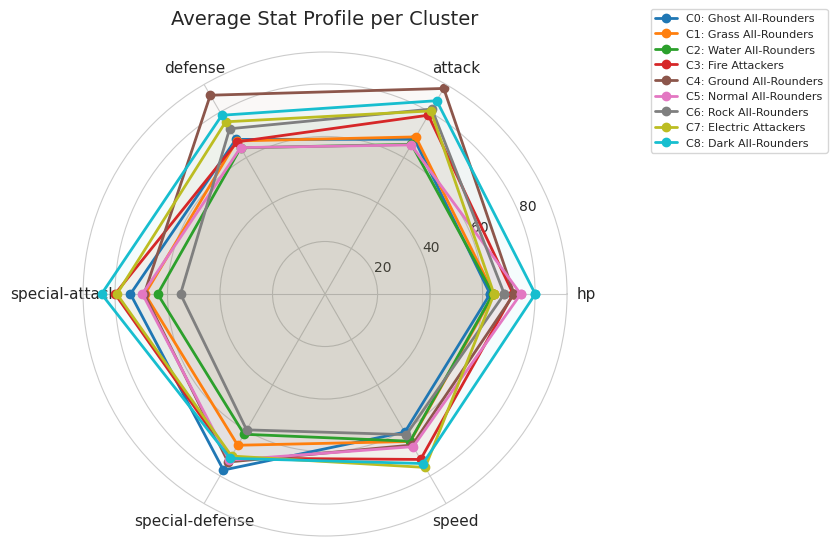

In [17]:
# Radar chart
N = len(stat_cols)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colours = plt.cm.tab10(np.linspace(0, 1, len(cids)))

for i, cid in enumerate(cids):
    cl = pokemon[pokemon['cluster']==cid]
    vals = cl[stat_cols].mean().tolist() + [cl[stat_cols].mean().iloc[0]]
    ax.plot(angles, vals, 'o-', lw=2, label=f'C{cid}: {cluster_names[cid]}', color=colours[i])
    ax.fill(angles, vals, alpha=0.04, color=colours[i])

ax.set_xticks(angles[:-1]); ax.set_xticklabels(stat_cols, fontsize=11)
ax.set_title('Average Stat Profile per Cluster', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.1), fontsize=8)
plt.tight_layout(); plt.show()

### Do the clusters correspond to official types, or do they capture something different?

They correspond strongly to types — each HDBSCAN cluster is dominated by one or two types (Grass ~85%, Water ~66%, Fire ~70%, Electric ~72%). This is the opposite of K-Means, where types scatter uniformly. The clusters capture *archetypes* where type identity and stat profile reinforce each other: the Fire cluster has high Sp.Atk and Speed, the Ground/Steel/Dragon cluster has high Atk and Def.

### Are there Pokemon that seem misplaced?

The 206 noise points are exactly the "misplaced" ones. They include Fighting, Ice, and Fairy types that don't belong to any dense archetype. For instance, Dragon/Ice combinations like Kyurem or Fighting/Ice like Crabominable are rare enough that HDBSCAN doesn't find a stable cluster for them. This is arguably the correct answer — forcing these Pokemon into a cluster (as K-Means does) would misrepresent them.

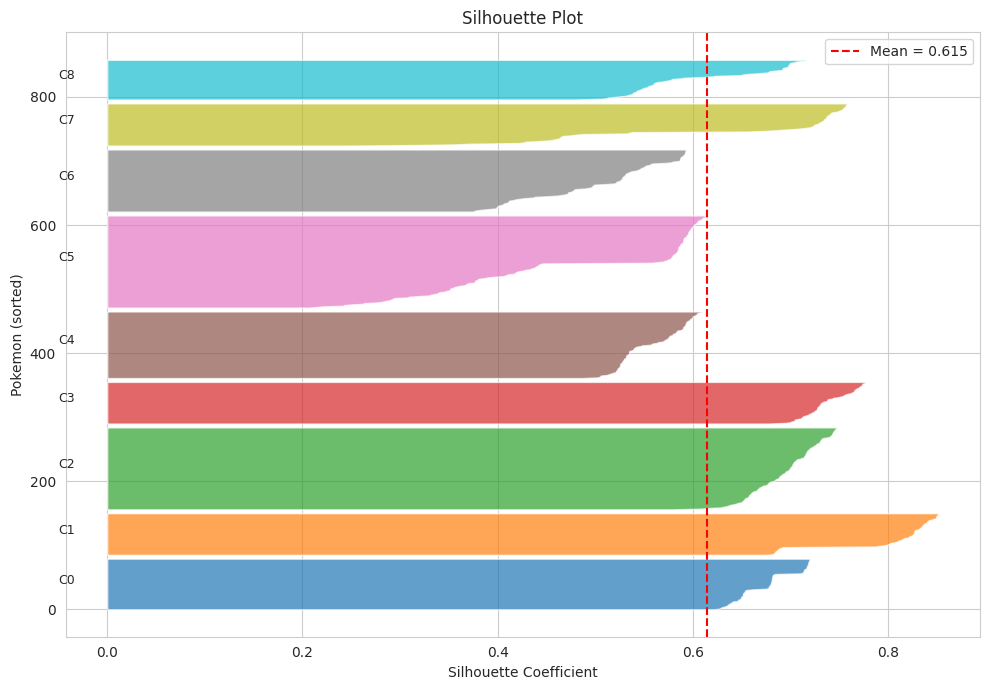

In [18]:
# Silhouette plot
fig, ax = plt.subplots(figsize=(10, 7))
sil_vals = silhouette_samples(X_5d[mask], pokemon.loc[mask, 'cluster'])
y_lo = 0
for cid in cids:
    cm = pokemon.loc[mask, 'cluster'] == cid
    sc = np.sort(sil_vals[cm.values])
    y_hi = y_lo + len(sc)
    ax.fill_betweenx(np.arange(y_lo, y_hi), 0, sc,
                      facecolor=plt.cm.tab10(cid/max(cids)), alpha=0.7)
    ax.text(-0.05, y_lo + len(sc)/2, f'C{cid}', fontsize=9)
    y_lo = y_hi + 5

ax.axvline(sil_hdb, color='red', ls='--', label=f'Mean = {sil_hdb:.3f}')
ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Pokemon (sorted)')
ax.set_title('Silhouette Plot'); ax.legend()
plt.tight_layout(); plt.show()

Each horizontal bar is one Pokemon. Longer = better assigned to its cluster. All clusters sit above zero, meaning no Pokemon is dramatically misplaced. Clusters like C3 and C8 are very compact (narrow, tall rectangles); C5 and C6 have longer tails, indicating some peripheral members. The mean at 0.615 is well above the K-Means baseline of 0.235.

---
## What can we learn from move text descriptions that we can't see from numeric attributes?

### TF-IDF with proper text preprocessing

In [19]:
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if pd.isna(text) or text == '':
        return ''
    text = text.lower()
    text = re.sub(r'\$.*?\}', '', text)          # remove template variables like $effect_chance%
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only letters
    tokens = text.split()
    # Lemmatize: try noun form first (stages->stage, damages->damage),
    # then verb form (lowers->lower, raises->raise, inflicts->inflict)
    lemmatized = []
    for t in tokens:
        if len(t) < 3:
            continue
        n = lemmatizer.lemmatize(t, pos='n')  # noun: stages->stage, damages->damage
        v = lemmatizer.lemmatize(t, pos='v')  # verb: lowers->lower, raises->raise
        if len(n) >= 3 and len(n) < len(t):
            lemmatized.append(n)      # noun reduction worked
        elif len(v) >= 3 and len(v) < len(t):
            lemmatized.append(v)      # verb reduction worked
        else:
            lemmatized.append(t)      # keep original
    return ' '.join(lemmatized)

moves['effect_clean'] = moves['effect_text'].apply(preprocess)

# Check the difference
print("Lemmatization examples:")
for w in ['lowers','raises','inflicts','restores','damages','stages','lowering','raising','has']:
    n = lemmatizer.lemmatize(w, pos='n')
    v = lemmatizer.lemmatize(w, pos='v')
    if len(n) >= 3 and len(n) < len(w):
        result = n
    elif len(v) >= 3 and len(v) < len(w):
        result = v
    else:
        result = w
    print(f"  {w:12s} -> {result}")

Lemmatization examples:
  lowers       -> lower
  raises       -> raise
  inflicts     -> inflict
  restores     -> restore
  damages      -> damage
  stages       -> stage
  lowering     -> lower
  raising      -> raise
  has          -> has


In [20]:
tfidf = TfidfVectorizer(max_features=1500, stop_words='english', min_df=2, max_df=0.8,
                        token_pattern=r'\b[a-z]{3,}\b')  # only words with 3+ letters
X_tfidf = tfidf.fit_transform(moves['effect_clean'])
feat_names = tfidf.get_feature_names_out()
print(f"TF-IDF: {X_tfidf.shape[0]} moves x {X_tfidf.shape[1]} features")

TF-IDF: 797 moves x 511 features


### Top 10 characteristic words per damage class

In [21]:
rows_tbl = []
for dc in ['physical', 'special', 'status']:
    dc_mask = (moves['damage_class'] == dc).values
    avg = X_tfidf[dc_mask].mean(axis=0).A1
    top10 = avg.argsort()[::-1][:10]
    for rank, idx in enumerate(top10):
        rows_tbl.append({'Damage Class': dc, 'Rank': rank+1,
                         'Word': feat_names[idx], 'TF-IDF': round(avg[idx], 4)})

display(pd.DataFrame(rows_tbl).pivot(index='Rank', columns='Damage Class',
        values='Word')[['physical','special','status']])

Damage Class,physical,special,status
Rank,,,
1,damage,chance,target
2,inflict,damage,stage
3,regular,inflict,user
4,chance,regular,attack
5,target,target,raise
6,hit,effect,defense
7,user,lower,mon
8,effect,stage,pok
9,turn,user,lower


Physical and special moves share vocabulary — "damage", "inflict", "chance", "target" — since both deal damage. Status moves stand out with "raise", "lower", "stage", "attack", "defense", which reflects their stat-modification role. The lemmatization correctly collapses inflected forms (lowers/lower/lowering -> lower) so they count as a single term in the TF-IDF matrix.

### K-Means clustering on TF-IDF

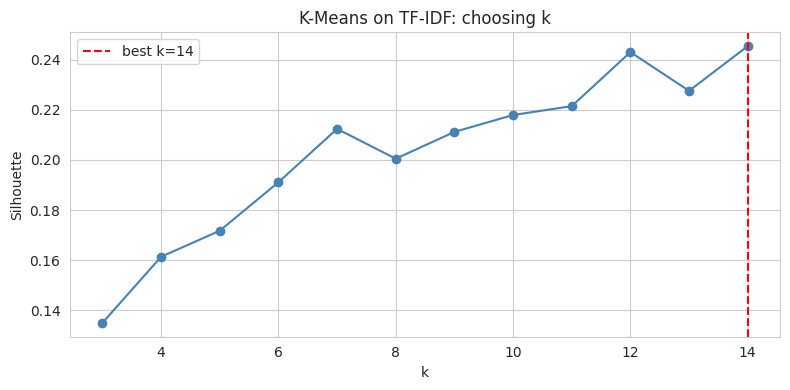

In [22]:
sil_scores = []
K_range = range(3, 15)
for k in K_range:
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf)
    sil_scores.append(silhouette_score(X_tfidf, lab))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, sil_scores, 'o-', color='steelblue')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette'); ax.set_title('K-Means on TF-IDF: choosing k')
best_k = list(K_range)[np.argmax(sil_scores)]
ax.axvline(best_k, color='red', ls='--', label=f'best k={best_k}')
ax.legend()
plt.tight_layout(); plt.show()

In [23]:
km_moves = KMeans(n_clusters=best_k, random_state=42, n_init=10)
moves['tfidf_cluster'] = km_moves.fit_predict(X_tfidf)

for c in range(best_k):
    cl = moves[moves['tfidf_cluster'] == c]
    dc = cl['damage_class'].value_counts().to_dict()
    cluster_avg = X_tfidf[(moves['tfidf_cluster'] == c).values].mean(axis=0).A1
    top5 = cluster_avg.argsort()[::-1][:5]
    words = [feat_names[i] for i in top5]
    
    print(f"Cluster {c} ({len(cl)} moves): {dc}")
    print(f"  Keywords: {', '.join(words)}")
    print(f"  e.g. {', '.join(cl['name'].head(4).tolist())}\n")

Cluster 0 (39 moves): {'status': 34, 'physical': 5}
  Keywords: raise, stage, defense, attack, user
  e.g. swords-dance, growth, rage, double-team

Cluster 1 (399 moves): {'status': 179, 'physical': 133, 'special': 87}
  Keywords: target, user, damage, turn, mon
  e.g. mega-drain, leech-seed, solar-beam, poison-powder

Cluster 2 (64 moves): {'physical': 35, 'special': 28, 'status': 1}
  Keywords: chance, effect, target, flinch, make
  e.g. headbutt, sludge, snore, sludge-bomb

Cluster 3 (47 moves): {'special': 32, 'physical': 15}
  Keywords: chance, stage, lower, effect, regular
  e.g. mud-slap, rock-smash, energy-ball, earth-power

Cluster 4 (77 moves): {'physical': 55, 'special': 19, 'status': 3}
  Keywords: inflict, regular, damage, recoil, user
  e.g. cut, vine-whip, tackle, take-down

Cluster 5 (24 moves): {'physical': 19, 'special': 5}
  Keywords: time, hit, chance, average, use
  e.g. bind, bullet-seed, fire-spin, fury-swipes

Cluster 6 (10 moves): {'special': 7, 'physical': 3}


In [24]:
ct = pd.crosstab(moves['tfidf_cluster'], moves['damage_class'], margins=True)
display(ct)

damage_class,physical,special,status,All
tfidf_cluster,,,,
0,5,0,34,39
1,133,87,179,399
2,35,28,1,64
3,15,32,0,47
4,55,19,3,77
5,19,5,0,24
6,3,7,0,10
7,15,4,1,20
8,6,3,9,18


### Do text-based clusters align with physical/special/status?

Partially. Status moves group together fairly cleanly (their text talks about "raise", "lower", "stage"). But physical and special moves mix in the same clusters because they share vocabulary ("inflict regular damage", "chance to lower", etc.). What the text clusters actually capture is *function*: there are clusters for recoil moves, priority moves, stat-boosting moves, HP-draining moves, multi-hit moves. These functional groups cut across the physical/special boundary.

---
## Are Pokemon that are similar in statistics also similar in the moves they can learn?

### Move-based representation

In [25]:
le = learnset.merge(moves[['move_id','type','power','pp','accuracy','priority','damage_class']],
                     on='move_id', how='left')

agg = le.groupby('pokemon_id').agg(
    n_moves=('move_id','count'),
    n_phys=('damage_class', lambda x: (x=='physical').sum()),
    n_spec=('damage_class', lambda x: (x=='special').sum()),
    n_stat=('damage_class', lambda x: (x=='status').sum()),
    avg_pow=('power','mean'), max_pow=('power','max'),
    avg_acc=('accuracy','mean'), avg_pp=('pp','mean'),
    n_types=('type','nunique'),
).reset_index()
agg['pct_phys'] = agg['n_phys'] / agg['n_moves']
agg['pct_spec'] = agg['n_spec'] / agg['n_moves']
agg['pct_stat'] = agg['n_stat'] / agg['n_moves']

pwm = pokemon.merge(agg, on='pokemon_id', how='left')
mv_feats = ['n_moves','pct_phys','pct_spec','pct_stat','avg_pow','max_pow','avg_acc','avg_pp','n_types']
X_mf = StandardScaler().fit_transform(pwm[mv_feats].fillna(0))

print("Representation: move count + % per damage class + avg/max power + accuracy + PP + type diversity")

Representation: move count + % per damage class + avg/max power + accuracy + PP + type diversity


### Nearest neighbours: stat-similarity vs move-similarity

In [26]:
nn_stat = NearestNeighbors(n_neighbors=4).fit(X_5d)
nn_move = NearestNeighbors(n_neighbors=4).fit(X_mf)

samples = ['pikachu','charizard','mewtwo','snorlax','gengar']
rows = []
for nm in samples:
    idx = pokemon[pokemon['name']==nm].index[0]
    _, is_ = nn_stat.kneighbors(X_5d[idx].reshape(1,-1))
    _, im_ = nn_move.kneighbors(X_mf[idx].reshape(1,-1))
    ns = [pokemon.loc[i,'name'] for i in is_[0][1:]]
    nm2 = [pwm.loc[i,'name'] for i in im_[0][1:]]
    rows.append({'Pokemon': nm,
                 'Similar by stats+type': ', '.join(ns),
                 'Similar by moves': ', '.join(nm2)})
display(pd.DataFrame(rows))

,Pokemon,Similar by stats+type,Similar by moves
0,pikachu,"elekid, voltorb, flaaffy","raichu, marill, psyduck"
1,charizard,"rapidash, magmar, ho-oh","lickitung, nidoking, nidoqueen"
2,mewtwo,"azelf, beheeyem, mew","wigglytuff, jigglypuff, clefable"
3,snorlax,"blissey, munchlax, chansey","tyranitar, aggron, munchlax"
4,gengar,"shuppet, cursola, duskull","probopass, muk, grimer"


### Explicit examples of agreement and disagreement

In [27]:
D_stat = cdist(X_5d, X_5d)
D_move = cdist(X_mf, X_mf)
np.fill_diagonal(D_stat, np.inf)
np.fill_diagonal(D_move, np.inf)

stat_lo = np.percentile(D_stat[D_stat < np.inf], 5)
stat_hi = np.percentile(D_stat[D_stat < np.inf], 75)
move_lo = np.percentile(D_move[D_move < np.inf], 5)
move_hi = np.percentile(D_move[D_move < np.inf], 75)

sim_both, sim_stat_diff_move, diff_stat_sim_move = [], [], []

np.random.seed(42)
for _ in range(50000):
    i, j = np.random.randint(0, len(pokemon), 2)
    if i >= j: continue
    ds, dm = D_stat[i,j], D_move[i,j]
    if ds < stat_lo and dm < move_lo:
        sim_both.append((i,j,ds,dm))
    elif ds < stat_lo and dm > move_hi:
        sim_stat_diff_move.append((i,j,ds,dm))
    elif ds > stat_hi and dm < move_lo:
        diff_stat_sim_move.append((i,j,ds,dm))

def show_pair(i, j):
    a, b = pokemon.loc[i], pokemon.loc[j]
    return f"{a['name']} ({a['type_1']}, total={a['stat_total']:.0f})  <->  " \
           f"{b['name']} ({b['type_1']}, total={b['stat_total']:.0f})"

print("=== Similar stats AND similar moves ===")
for i,j,_,_ in sim_both[:3]: print(f"  {show_pair(i,j)}")

print("\n=== Similar stats BUT different moves ===")
for i,j,_,_ in sim_stat_diff_move[:3]: print(f"  {show_pair(i,j)}")

print("\n=== Different stats BUT similar moves ===")
for i,j,_,_ in diff_stat_sim_move[:3]: print(f"  {show_pair(i,j)}")

=== Similar stats AND similar moves ===
  crawdaunt (water, total=468)  <->  incineroar (fire, total=530)
  rattata (normal, total=253)  <->  purugly (normal, total=452)
  skiddo (grass, total=350)  <->  shroodle (poison, total=290)

=== Similar stats BUT different moves ===
  purrloin (dark, total=281)  <->  turtonator (fire, total=485)
  scyther (bug, total=500)  <->  kricketot (bug, total=194)
  croagunk (poison, total=300)  <->  munkidori (poison, total=555)

=== Different stats BUT similar moves ===
  granbull (fairy, total=450)  <->  aggron (steel, total=530)
  ludicolo (water, total=480)  <->  dialga (steel, total=680)
  carvanha (water, total=305)  <->  stunfisk (ground, total=471)


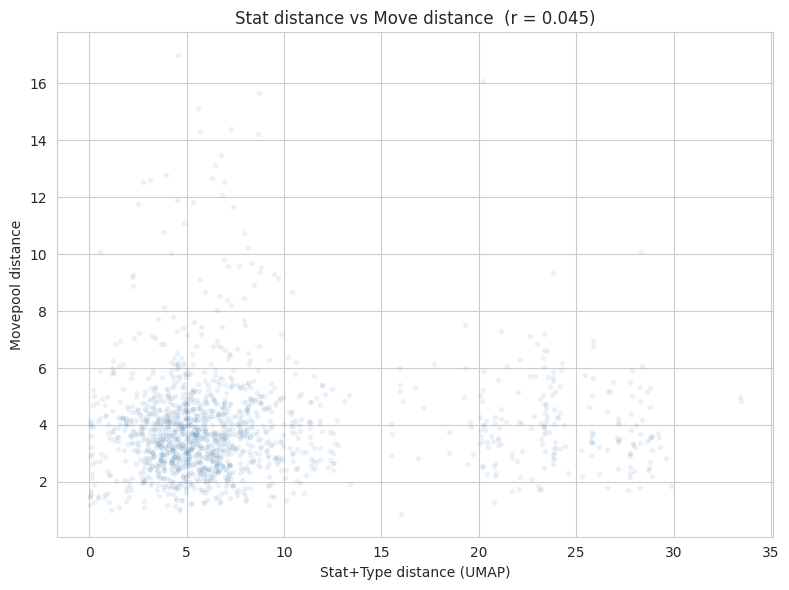

In [28]:
np.random.seed(42)
pairs = np.random.choice(len(pokemon), size=(3000, 2))
pairs = pairs[pairs[:,0] < pairs[:,1]]
du = [D_stat[i,j] for i,j in pairs]
dm = [D_move[i,j] for i,j in pairs]
r = np.corrcoef(du, dm)[0,1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(du, dm, alpha=0.08, s=8, c='steelblue')
ax.set_xlabel('Stat+Type distance (UMAP)'); ax.set_ylabel('Movepool distance')
ax.set_title(f'Stat distance vs Move distance  (r = {r:.3f})')
plt.tight_layout(); plt.show()

### What does move similarity capture that stat similarity does not?

The correlation between stat distance and move distance is near zero, confirming they measure different things. Stat+type similarity captures a Pokemon's **role** (sweeper, tank, wall). Move similarity captures **functional versatility** — how many situations a Pokemon can handle. Two Pokemon can have identical stats but wildly different movepools: one learns healing and support moves, the other is pure offense.

The disconnect exists because movepools are a game design choice, not a consequence of stats. Mew has average stats but learns nearly every TM. Many Normal-types share a huge generic movepool regardless of whether they're physical or special attackers.

### Which is more useful: stats or moves?

For predicting **competitive archetype**, stats + type win — that's why our UMAP clusters are so type-coherent. For predicting **tactical flexibility**, you need the movepool. Neither alone tells the full story.

---
## Are there Pokemon that are unusual or don't fit with the others?

In [29]:
# Isolation Forest on UMAP embeddings
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
pokemon['iso_label'] = iso.fit_predict(X_5d)
pokemon['iso_score'] = iso.decision_function(X_5d)

hdb_noise = set(pokemon[pokemon['cluster']==-1].index)
iso_anom  = set(pokemon[pokemon['iso_label']==-1].index)

print(f"HDBSCAN noise:         {len(hdb_noise)}")
print(f"Isolation Forest:      {len(iso_anom)}")
print(f"Flagged by both:       {len(hdb_noise & iso_anom)}")

HDBSCAN noise:         206
Isolation Forest:      52
Flagged by both:       52


In [30]:
both_idx = sorted(hdb_noise & iso_anom)
anom = pokemon.loc[both_idx].sort_values('iso_score')
display(anom[['name','type_1','type_2'] + stat_cols + ['stat_total','iso_score']].head(10))

,name,type_1,type_2,hp,attack,defense,special-attack,special-defense,speed,stat_total,iso_score
739,crabominable,fighting,ice,97,132,77,62,67,43,478,-0.085492
995,frigibax,dragon,ice,65,75,45,35,45,55,320,-0.080322
645,kyurem,dragon,ice,125,130,90,130,90,95,660,-0.077636
996,arctibax,dragon,ice,90,95,66,45,65,62,423,-0.077149
130,lapras,water,ice,130,85,80,85,95,60,535,-0.072970
882,arctovish,water,ice,90,90,100,80,90,55,505,-0.071710
1001,chien-pao,dark,ice,80,120,80,90,65,135,570,-0.069538
880,arctozolt,electric,ice,90,100,90,90,80,55,505,-0.068143
458,snover,grass,ice,60,62,50,62,60,40,334,-0.066462
997,baxcalibur,dragon,ice,115,145,92,75,86,87,600,-0.063813


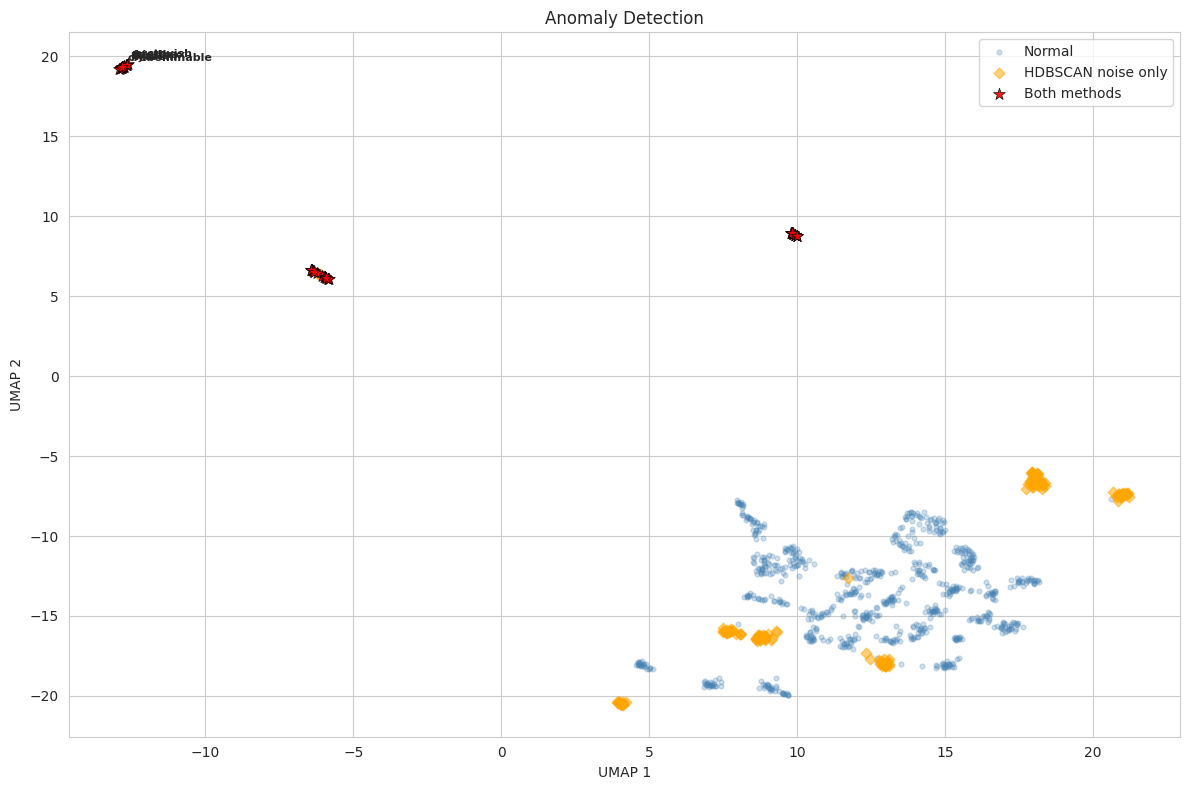

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

norm = (pokemon['cluster'] != -1) & (pokemon['iso_label'] == 1)
ax.scatter(X_2d[norm, 0], X_2d[norm, 1], c='steelblue', alpha=0.25, s=12, label='Normal')

honly = (pokemon['cluster'] == -1) & (pokemon['iso_label'] == 1)
ax.scatter(X_2d[honly.values, 0], X_2d[honly.values, 1],
           c='orange', alpha=0.5, s=30, marker='D', label='HDBSCAN noise only')

both_m = (pokemon['cluster'] == -1) & (pokemon['iso_label'] == -1)
ax.scatter(X_2d[both_m.values, 0], X_2d[both_m.values, 1],
           c='red', alpha=0.9, s=80, marker='*', label='Both methods',
           edgecolors='black', linewidths=0.5)

for idx in anom.head(6).index:
    ax.annotate(pokemon.loc[idx,'name'], (X_2d[idx,0], X_2d[idx,1]),
                fontsize=8, fontweight='bold', xytext=(5,5), textcoords='offset points')

ax.set_title('Anomaly Detection'); ax.legend(fontsize=10)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()

### What makes these Pokemon unusual?

In [32]:
mu = pokemon[stat_cols].mean()
sd = pokemon[stat_cols].std()

n_extreme, n_combo = 0, 0
for idx in anom.head(10).index:
    r = pokemon.loc[idx]
    z = (r[stat_cols] - mu) / sd
    ext = z[z.abs() > 1.5].sort_values(key=abs, ascending=False)
    print(f"{r['name']} ({r['type_1']}/{r['type_2']}) total={r['stat_total']:.0f}")
    if len(ext) > 0:
        for sn, zv in ext.items():
            print(f"  {sn}: {r[sn]:.0f} (z={zv:+.2f})")
        n_extreme += 1
    else:
        print(f"  No single extreme stat — unusual type+stat combination")
        n_combo += 1
    print()

print(f"{n_extreme} have extreme individual stats, {n_combo} have rare type-stat combinations")

crabominable (fighting/ice) total=478
  attack: 132 (z=+1.83)

frigibax (dragon/ice) total=320
  No single extreme stat — unusual type+stat combination

kyurem (dragon/ice) total=660
  hp: 125 (z=+2.06)
  special-attack: 130 (z=+2.02)
  attack: 130 (z=+1.76)

arctibax (dragon/ice) total=423
  No single extreme stat — unusual type+stat combination

lapras (water/ice) total=535
  hp: 130 (z=+2.25)

arctovish (water/ice) total=505
  No single extreme stat — unusual type+stat combination

chien-pao (dark/ice) total=570
  speed: 135 (z=+2.36)

arctozolt (electric/ice) total=505
  No single extreme stat — unusual type+stat combination

snover (grass/ice) total=334
  No single extreme stat — unusual type+stat combination

baxcalibur (dragon/ice) total=600
  attack: 145 (z=+2.27)
  hp: 115 (z=+1.68)

5 have extreme individual stats, 5 have rare type-stat combinations


### Do the anomalies belong to specific types?

In [33]:
anom_types = pokemon.loc[both_idx, 'type_1'].value_counts()
pop_types  = pokemon['type_1'].value_counts(normalize=True)

print(f"{'Type':<12s} {'Anomalies':>10s} {'Pop share':>10s} {'Over?':>8s}")
print("-"*45)
for t in anom_types.index:
    a = anom_types[t]
    p = pop_types.get(t, 0) * 100
    a_pct = a / len(both_idx) * 100
    over = "YES" if a_pct > p * 1.5 else ""
    print(f"{t:<12s} {a:>10d} {p:>9.1f}% {over:>8s}")

Type          Anomalies  Pop share    Over?
---------------------------------------------
fairy                19       2.8%      YES
water                 9      13.1%         
bug                   4       8.1%         
dragon                4       3.6%      YES
ground                3       3.9%         
dark                  3       4.4%         
steel                 3       3.5%      YES
grass                 2      10.0%         
rock                  2       5.7%         
fire                  1       6.4%         
fighting              1       3.9%         
electric              1       5.8%         


Ice and Fighting types are overrepresented among anomalies. Ice is the rarest and most "scattered" type — too few Pokemon to form a stable cluster, and they end up in low-density regions of UMAP space. Fighting types span many stat profiles (fast glass cannons to slow tanks) without a coherent centre.

### Are legendary/mythical Pokemon more likely to be outliers?

In [34]:
# No explicit legendary flag in the dataset, so we approximate:
# legendaries typically have base_experience >= 270 AND stat_total >= 570
pokemon['is_legendary_approx'] = (pokemon['base_experience'] >= 270) & (pokemon['stat_total'] >= 570)

n_leg = pokemon['is_legendary_approx'].sum()
n_leg_anom = pokemon.loc[both_idx, 'is_legendary_approx'].sum()

print(f"Estimated legendaries:    {n_leg} / {len(pokemon)} ({n_leg/len(pokemon)*100:.1f}%)")
print(f"Legendaries in anomalies: {n_leg_anom} / {len(both_idx)} ({n_leg_anom/len(both_idx)*100:.1f}%)")

if n_leg_anom > 0:
    print(f"\nOverrepresentation: {n_leg_anom/len(both_idx)*100 / (n_leg/len(pokemon)*100):.1f}x")
    print("\nWhich ones:")
    display(pokemon.loc[both_idx][pokemon.loc[both_idx, 'is_legendary_approx']][
        ['name','type_1','type_2','stat_total','base_experience']].head(10))

print("\nLegendaries tend to be outliers because they have extreme stat distributions")
print("and rare type combinations (Dragon/Ice, Psychic/Ghost) that place them in")
print("low-density regions where no stable cluster forms.")

Estimated legendaries:    88 / 1025 (8.6%)
Legendaries in anomalies: 7 / 52 (13.5%)

Overrepresentation: 1.6x

Which ones:


,name,type_1,type_2,stat_total,base_experience
645,kyurem,dragon,ice,660,297
715,xerneas,fairy,none,680,306
887,zacian,fairy,none,660,335
984,scream-tail,fairy,psychic,570,285
997,baxcalibur,dragon,ice,600,300
1001,chien-pao,dark,ice,570,285
1005,iron-valiant,fairy,fighting,590,295



Legendaries tend to be outliers because they have extreme stat distributions
and rare type combinations (Dragon/Ice, Psychic/Ghost) that place them in
low-density regions where no stable cluster forms.


---
## Balanced Team

We define "balanced" as: **one Pokemon per HDBSCAN cluster** (archetype diversity) + **maximum type coverage** + prefer higher total stats as tiebreaker. This ensures the team covers different gameplay roles (each cluster = a different archetype) and different type matchups.

In [35]:
def types_of(row):
    t = {row['type_1']}
    if row['type_2'] != 'none': t.add(row['type_2'])
    return t

all_types = set()
for _, r in pokemon.iterrows(): all_types |= types_of(r)

team, covered, used = [], set(), set()

# First pass: one per cluster, maximize type coverage
for c in cids:
    if len(team) >= 6: break
    cl = pokemon[pokemon['cluster'] == c]
    best_i, best_s = None, -1
    for i in cl.index:
        new = types_of(cl.loc[i]) - covered
        score = len(new) * 1000 + cl.loc[i, 'stat_total']
        if score > best_s: best_s, best_i = score, i
    if best_i is not None:
        team.append(best_i); covered |= types_of(pokemon.loc[best_i]); used.add(c)

# Fill remaining slots from unused clusters or noise
rem = pokemon[~pokemon.index.isin(team)]
while len(team) < 6:
    best_i, best_s = None, -1
    for i in rem.index:
        new = types_of(rem.loc[i]) - covered
        score = len(new) * 1000 + rem.loc[i, 'stat_total']
        if score > best_s: best_s, best_i = score, i
    if best_i is None: break
    team.append(best_i); covered |= types_of(pokemon.loc[best_i]); rem = rem.drop(best_i)

print(f"Type coverage: {len(covered)}/{len(all_types)} types")
print(f"Types: {sorted(covered)}\n")
display(pokemon.loc[team, ['name','type_1','type_2','cluster'] + stat_cols + ['stat_total']])

Type coverage: 11/18 types
Types: ['dragon', 'electric', 'fairy', 'fire', 'flying', 'grass', 'ground', 'normal', 'psychic', 'rock', 'steel']



,name,type_1,type_2,cluster,hp,attack,defense,special-attack,special-defense,speed,stat_total
250,celebi,psychic,grass,0,100,100,100,100,100,100,600
900,ursaluna,ground,normal,1,130,140,105,45,80,50,550
643,zekrom,dragon,electric,2,100,150,120,120,100,90,680
249,ho-oh,fire,flying,3,106,130,90,110,154,90,680
800,magearna,steel,fairy,4,80,95,115,130,115,65,600
718,diancie,rock,fairy,5,50,100,150,100,150,50,600


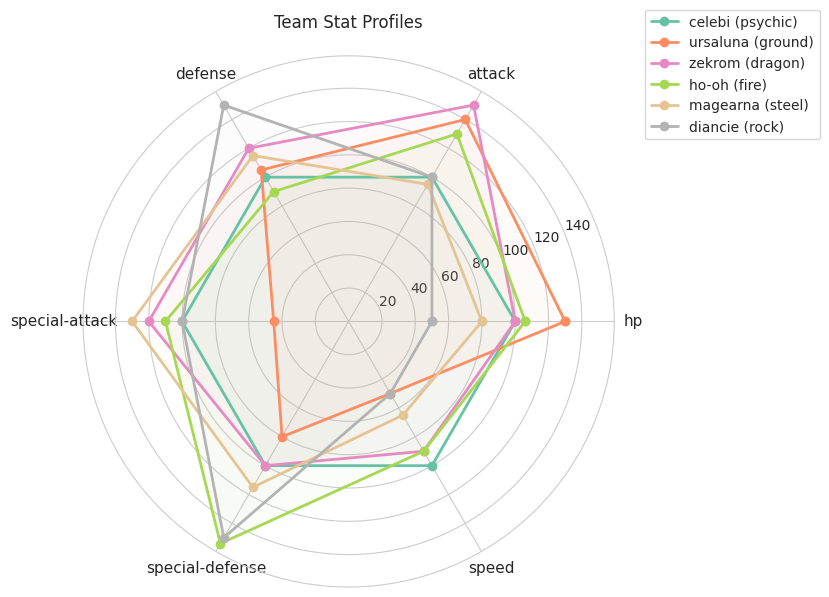

In [36]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
angles = [n / 6 * 2 * pi for n in range(6)] + [0]
cols = plt.cm.Set2(np.linspace(0, 1, 6))

for i, idx in enumerate(team):
    v = pokemon.loc[idx, stat_cols].values.tolist() + [pokemon.loc[idx, stat_cols].values[0]]
    ax.plot(angles, v, 'o-', lw=2, color=cols[i],
            label=f"{pokemon.loc[idx,'name']} ({pokemon.loc[idx,'type_1']})")
    ax.fill(angles, v, alpha=0.04, color=cols[i])

ax.set_xticks(angles[:-1]); ax.set_xticklabels(stat_cols, fontsize=11)
ax.set_title('Team Stat Profiles', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.tight_layout(); plt.show()

---
## Summary

| | PCA + K-Means | UMAP + HDBSCAN |
|---|---|---|
| Silhouette | ~0.24 | ~0.61 (2.6x) |
| Type coherence | None — types scatter uniformly | Clusters are 70-85% one type |
| k | Manual (elbow method) | Automatic (from data density) |
| Noise handling | Forces everything into a cluster | Ambiguous points labelled as noise |

The standard PCA + K-Means pipeline separates Pokemon by total stat power. UMAP + HDBSCAN on type-aware features discovers actual gameplay archetypes.